# Lista 4 - Tomasz Jarmoc & Mateusz Izdebski

In [15]:
import sympy as sp
from sympy import symbols, diff, solve, sqrt, Matrix, simplify
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sp.init_printing(use_unicode=True)
x, y, z, l = symbols('x y z l')

## Zadanie 1 

In [38]:
# I SPOSÓB - METODA MNOŻNIKÓW LAGRANGA

f = 6 - sqrt(3*x**2 + 3*y**2)
g = y - x - 1

L = f - l*g
dLdl = diff(L, l)
dLdx = diff(L, x)
dLdy = diff(L, y)

print("f(x,y) = ")
display(f)
print("g(x,y) = ")
display(g)
print()

critical_points_raw = solve([dLdl, dLdx, dLdy], [x, y, l], dict=True)
critical_points = critical_points_raw if isinstance(critical_points_raw, list) else [critical_points_raw]

for i, cp in enumerate(critical_points):
    if isinstance(cp, dict):
        x0 = cp[x]
        y0 = cp[y]
        l0 = cp[l]
        
        dg_dx = diff(g, x)
        dg_dy = diff(g, y)
        dL_dxx = diff(L, x, 2)
        dL_dyy = diff(L, y, 2)
        dL_dxy = diff(L, x, y)
        
        H = Matrix([[0, dg_dx, dg_dy], [dg_dx, dL_dxx, dL_dxy], [dg_dy, dL_dxy, dL_dyy]])
        H_vals = H.subs({x: x0, y: y0})
        delta2 = H_vals.det()
        
        print(f"Punkt: xo = {x0}, yo = {y0}, lambda_o = {l0}")
        print(f"\nMacierz:")
        display(H_vals)
        print(f"\n Wyznacznik macierzy =")
        display(delta2)
        print(f"Typ: {'MAKSIMUM' if delta2 > 0 else 'MINIMUM' if delta2 < 0 else '??'}\n")
        print("Wartość funkcji:")
        display(f.subs({x: x0, y: y0}))
        print()
        
        global_cp_list = [(x0, y0)]

f(x,y) = 


g(x,y) = 



Punkt: xo = -1/2, yo = 1/2, lambda_o = -sqrt(6)/2

Macierz:


⎡0    -1    1  ⎤
⎢              ⎥
⎢    -√6   -√6 ⎥
⎢-1  ────  ────⎥
⎢     2     2  ⎥
⎢              ⎥
⎢    -√6   -√6 ⎥
⎢1   ────  ────⎥
⎣     2     2  ⎦


 Wyznacznik macierzy =


Typ: MAKSIMUM

Wartość funkcji:


Funkcja zredukowana (po podstawieniu y = x+1):
f(x) =


Punkt ekstremum:
  x =


  y =


  f =


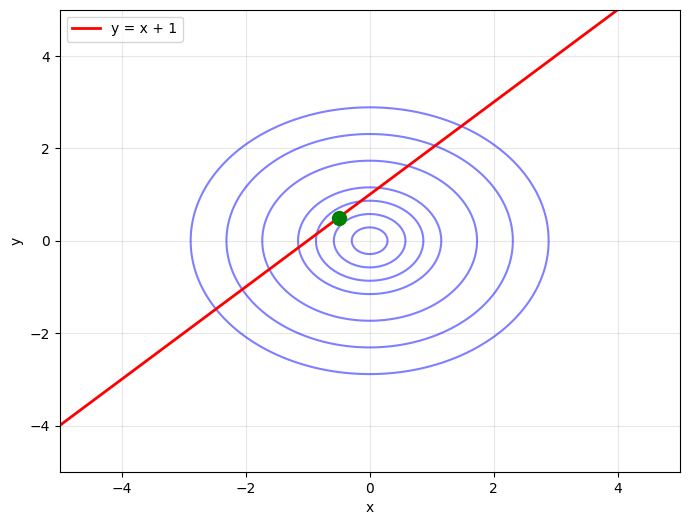

In [ ]:
# II SPOSÓB - METODA GRAFICZNA

expr = 6*x**2 + 6*x + 3
f_reduced = 6 - sqrt(expr)
df_reduced = diff(f_reduced, x)

print("Funkcja zredukowana (po podstawieniu y = x+1):")
print("f(x) =")
display(f_reduced)

critical_x = solve(df_reduced, x)

fig, ax = plt.subplots(figsize=(8, 6))

x_vals = np.linspace(-5, 5, 300)
y_vals = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x_vals, y_vals)
Z = 6 - np.sqrt(3*X**2 + 3*Y**2)

ax.set_title(r'Warstewnice: $z = 6 - \sqrt{3x^2 + 3y^2}$', fontsize=12, fontweight='bold')
ax.contour(X, Y, Z, levels=[1, 2, 3, 4, 4.5, 5, 5.5, 6], colors='blue', alpha=0.5)
x_line = np.linspace(-5, 4, 100)
y_line = x_line + 1
ax.plot(x_line, y_line, 'r-', linewidth=2, label='y = x + 1')

for x_crit in critical_x:
    if x_crit.is_real:
        y_crit = x_crit + 1
        f_crit = f_reduced.subs(x, x_crit)
        ax.plot(float(x_crit.evalf()), float(y_crit.evalf()), 'go', markersize=10)
        print("Punkt ekstremum:")
        print(f"  x =")
        display(x_crit)
        print(f"  y =")
        display(y_crit)
        print(f"  f =")
        display(f_crit)
        print()

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [24]:
print("SPROWADZENIE DO EKSTREMUM LOKALNEGO\n")

f_single = 6 - sqrt(6*x**2 + 6*x + 3)
df_dx = diff(f_single, x)
d2f_dx2 = diff(df_dx, x)

print("Funkcja jednej zmiennej:")
print("f(x) =")
display(f_single)
print()

critical_points_x = solve(df_dx, x)
max_point = None
max_value = -float('inf')

for x_crit in critical_points_x:
    if x_crit.is_real:
        y_crit = x_crit + 1
        z_crit = f_single.subs(x, x_crit)
        d2f_val = d2f_dx2.subs(x, x_crit)
        
        ekstremum_type = "MAX" if d2f_val < 0 else "MIN" if d2f_val > 0 else "?"
        z_val = float(z_crit.evalf())
        
        print(f"xo =")
        display(x_crit)
        print(f"yo =")
        display(y_crit)
        print(f"f''(xo) =")
        display(d2f_val)
        print(f"→ {ekstremum_type}\n")
        print(f"f(xo, yo) =")
        display(z_crit)
        print()
        
        if ekstremum_type == "MAX" and z_val > max_value:
            max_value = z_val
            max_point = (x_crit, y_crit, z_crit)

SPROWADZENIE DO EKSTREMUM LOKALNEGO

Funkcja jednej zmiennej:
f(x) =



xo =


yo =


f''(xo) =


→ MAX

f(xo, yo) =


## Zadanie 2

In [27]:
f2 = x**4 - 2*y**3 + 2*x**2*y - x**2 + 2*y

print("f(x, y) =")
display(f2)

# pochodne
f2_x = diff(f2, x)          # f'_x
f2_y = diff(f2, y)          # f'_y
f2_xx = diff(f2, x, 2)      # f''_xx
f2_xxx = diff(f2, x, 3)     # f'''_xxx
f2_xxy = diff(f2_xxx, y)    # f'''_xxy
f2_yxy = diff(f2, y, 2, x)  # f'''_yxy
f2_yyx = diff(f2, y, 2, x)  # f'''_yyx

points = {
    "f'_x(1.11, 1.22)": (f2_x, 1.11, 1.22),
    "f'_y(2.22, 2.11)": (f2_y, 2.22, 2.11),
    "f'''_xxx(3.33, 4.33)": (f2_xxx, 3.33, 4.33),
    "f'''_xxy(4.44, 3.44)": (f2_xxy, 4.44, 3.44),
    "f'''_yxy(3.33, 4.33)": (f2_yxy, 3.33, 4.33),
    "f'''_yyx(4.44, 3.44)": (f2_yyx, 4.44, 3.44),
}

for label, (derivative, x_val, y_val) in points.items():
    result = derivative.subs([(x, x_val), (y, y_val)])
    result_float = float(result)
    print(f"\n{label} =")
    display(result)

f(x, y) =



f'_x(1.11, 1.22) =



f'_y(2.22, 2.11) =



f'''_xxx(3.33, 4.33) =



f'''_xxy(4.44, 3.44) =



f'''_yxy(3.33, 4.33) =



f'''_yyx(4.44, 3.44) =


## Zadanie 3

Punkty stacjonarne:
f'_x =


f'_y =



Rozwiązania: [{x: 0, y: -sqrt(3)/3}, {x: 0, y: sqrt(3)/3}, {x: -sqrt(2/3 - sqrt(19)/6), y: -1/6 + sqrt(19)/6}, {x: sqrt(2/3 - sqrt(19)/6), y: -1/6 + sqrt(19)/6}, {x: -sqrt(2/3 + sqrt(19)/6), y: -sqrt(19)/6 - 1/6}, {x: sqrt(2/3 + sqrt(19)/6), y: -sqrt(19)/6 - 1/6}]

Punkt P1 = 


Macierz Hessego:


⎡  4⋅√3          ⎤
⎢- ──── - 2   0  ⎥
⎢   3            ⎥
⎢                ⎥
⎣    0       4⋅√3⎦

delta1 = f''_xx =


delta2 = det(H) =


Typ: PUNKT SIODŁOWY
f(P) =



Punkt P2 = 


Macierz Hessego:


⎡     4⋅√3       ⎤
⎢-2 + ────    0  ⎥
⎢      3         ⎥
⎢                ⎥
⎣    0      -4⋅√3⎦

delta1 = f''_xx =


delta2 = det(H) =


Typ: PUNKT SIODŁOWY
f(P) =



Punkt P3 = 


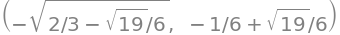

Macierz Hessego:


⎡                         _________⎤
⎢   16   4⋅√19           ╱ 2   √19 ⎥
⎢   ── - ─────     -4⋅  ╱  ─ - ─── ⎥
⎢   3      3          ╲╱   3    6  ⎥
⎢                                  ⎥
⎢       _________                  ⎥
⎢      ╱ 2   √19                   ⎥
⎢-4⋅  ╱  ─ - ───      2 - 2⋅√19    ⎥
⎣   ╲╱   3    6                    ⎦

delta1 = f''_xx =


delta2 = det(H) =


Typ: MAKSIMUM LOKALNE
f(P) =



Punkt P4 = 


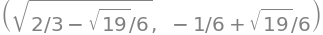

Macierz Hessego:


⎡                       _________⎤
⎢  16   4⋅√19          ╱ 2   √19 ⎥
⎢  ── - ─────     4⋅  ╱  ─ - ─── ⎥
⎢  3      3         ╲╱   3    6  ⎥
⎢                                ⎥
⎢      _________                 ⎥
⎢     ╱ 2   √19                  ⎥
⎢4⋅  ╱  ─ - ───      2 - 2⋅√19   ⎥
⎣  ╲╱   3    6                   ⎦

delta1 = f''_xx =


delta2 = det(H) =


Typ: MAKSIMUM LOKALNE
f(P) =



Punkt P5 = 


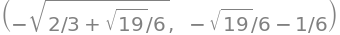

Macierz Hessego:


⎡                         _________⎤
⎢   16   4⋅√19           ╱ 2   √19 ⎥
⎢   ── + ─────     -4⋅  ╱  ─ + ─── ⎥
⎢   3      3          ╲╱   3    6  ⎥
⎢                                  ⎥
⎢       _________                  ⎥
⎢      ╱ 2   √19                   ⎥
⎢-4⋅  ╱  ─ + ───      2 + 2⋅√19    ⎥
⎣   ╲╱   3    6                    ⎦

delta1 = f''_xx =


delta2 = det(H) =


Typ: MINIMUM LOKALNE
f(P) =



Punkt P6 = 


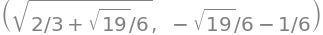

Macierz Hessego:


⎡                       _________⎤
⎢  16   4⋅√19          ╱ 2   √19 ⎥
⎢  ── + ─────     4⋅  ╱  ─ + ─── ⎥
⎢  3      3         ╲╱   3    6  ⎥
⎢                                ⎥
⎢      _________                 ⎥
⎢     ╱ 2   √19                  ⎥
⎢4⋅  ╱  ─ + ───      2 + 2⋅√19   ⎥
⎣  ╲╱   3    6                   ⎦

delta1 = f''_xx =


delta2 = det(H) =


Typ: MINIMUM LOKALNE
f(P) =


In [31]:
def classify_point(f, vars_, point):
    H = sp.hessian(f, vars_)
    H0 = H.subs(dict(zip(vars_, point)))
    detH = sp.simplify(H0.det())
    f_xx = sp.simplify(sp.diff(f, vars_[0], 2).subs(dict(zip(vars_, point))))
    
    if detH > 0 and f_xx > 0:
        kind = "MINIMUM LOKALNE"
    elif detH > 0 and f_xx < 0:
        kind = "MAKSIMUM LOKALNE"
    elif detH < 0:
        kind = "PUNKT SIODŁOWY"
    else:
        kind = "TEST NIEROZSTRZYGAJĄCY"
    
    return H0, detH, f_xx, kind

def critical_points(f, vars_):
    grads = [diff(f, v) for v in vars_]
    return solve(grads, vars_, dict=True)

print("Punkty stacjonarne:")
print("f'_x =")
display(f2_x)
print("f'_y =")
display(f2_y)

sols = critical_points(f2, (x, y))
print(f"\nRozwiązania: {sols}")

for i, sol in enumerate(sols, 1):
    pt = (sol[x], sol[y])
    print(f"\nPunkt P{i} = ")
    display(pt)
    
    H0, detH, f_xx, kind = classify_point(f2, (x, y), pt)
    
    print("Macierz Hessego:")
    display(H0)
    print("delta1 = f''_xx =")
    display(f_xx)
    print("delta2 = det(H) =")
    display(detH)
    print(f"Typ: {kind}")
    print("f(P) =")
    display(sp.simplify(f2.subs(sol)))

## Zadanie 4

In [35]:
# Punkt M
p1, p2 = 1, 1

# Pochodne cząstkowe w punkcie M
fx_p = f2_x.subs({x: p1, y: p2}) 
fy_p = f2_y.subs({x: p1, y: p2})  
f_p = f2.subs({x: p1, y: p2})    

print("Płaszczyzna styczna do wykresu funkcji w punkcie M = (1, 1)\n")
print(f"Punkt M: ({p1}, {p2})")
print(f"f({p1}, {p2}) =")
display(f_p)

print(f"f'_x({p1}, {p2}) =")
display(fx_p)

print(f"f'_y({p1}, {p2}) =")
display(fy_p)

# Równanie płaszczyzny stycznej
print("Równanie płaszczyzny stycznej")
print("\nPostać ogólna:")
print("f'_x(1,1)(x-1) + f'_y(1,1)(y-1) = z - f(1,1)")

eq_left = fx_p * (x - p1) + fy_p * (y - p2)
z_expr = f_p + eq_left

display(eq_left)
print("= z -")
display(f_p)


Płaszczyzna styczna do wykresu funkcji w punkcie M = (1, 1)

Punkt M: (1, 1)
f(1, 1) =


f'_x(1, 1) =


f'_y(1, 1) =


Równanie płaszczyzny stycznej

Postać ogólna:
f'_x(1,1)(x-1) + f'_y(1,1)(y-1) = z - f(1,1)


= z -


## Zadanie 5

In [37]:
# Punkt M i wektor kierunku
M = [2, 3]
v_vec = sp.Matrix([1, 2])

# gradiencink funkcji w punkcie M(2, 3)
grad_x = f2_x.subs({x: M[0], y: M[1]})
grad_y = f2_y.subs({x: M[0], y: M[1]})
gradient = sp.Matrix([grad_x, grad_y])

# normalizowanko wektora kierunku
v_norm = sp.sqrt(v_vec.dot(v_vec))
v_unit = v_vec / v_norm

# pochodna kierunkowa zgodnie ze wzorem z wykladu
directional_deriv = gradient.dot(v_unit)

print("Pochodna kierunkowa w punkcie M = (2, 3) w kierunku v = [1, 2]\n")
print("Gradient funkcji w punkcie M = (2, 3):")
print(f"f(2, 3) = ({grad_x}, {grad_y})")
display(gradient.T)

print(f"\nWektor kierunku: v = [1, 2]")
display(v_norm)

print("\nWektor jednostkowy: v/|v|")
display(v_unit.T)

print("\nPochodna kierunkowa:")
print(f"f'_v(M) =")
display(directional_deriv)
print(f"\nWartość zaokraglona: {float(directional_deriv):.6f}")


Pochodna kierunkowa w punkcie M = (2, 3) w kierunku v = [1, 2]

Gradient funkcji w punkcie M = (2, 3):
f(2, 3) = (52, -44)


[52  -44]


Wektor kierunku: v = [1, 2]



Wektor jednostkowy: v/|v|


⎡√5  2⋅√5⎤
⎢──  ────⎥
⎣5    5  ⎦


Pochodna kierunkowa:
f'_v(M) =



Wartość zaokraglona: -16.099689
